# NB01: Curación clínica y supervivencia HNSC

Primer notebook del pipeline SupraGraphNet. A partir de los archivos clínicos crudos de TCGA-HNSC construye la cohorte de entrenamiento, selecciona la única variable clínica con señal independiente (HPV status) y genera los targets de supervivencia alineados con las ómicas del NB02.

**Entradas:** `survival_HNSC_survival.txt`, `HNSC.clin.merged.picked.txt`, `nationwidechildrens.org_auxiliary_hnsc.txt`

**Salidas:** `survival_targets_all_patients.csv`, `barcodes_por_tipo_muestra.json`, `hpv_encoded.csv`

**Regla de datos:** todos los filtros se calculan exclusivamente sobre muestras tumorales. Las 74 muestras normales (-11) se reservan para el sanity check biológico del NB04.



## PASO 0: Setup y rutas

Montaje de Drive, instalación de dependencias y declaración de todas las rutas del proyecto.

In [1]:
from google.colab import drive
import os, sys
drive.mount('/content/drive')
carpeta_proyecto = '/content/drive/MyDrive/TFM'
os.chdir(carpeta_proyecto)
sys.path.append(carpeta_proyecto)
print('Directorio de trabajo actual:', os.getcwd())

Mounted at /content/drive
Directorio de trabajo actual: /content/drive/MyDrive/TFM


In [2]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.0 MB/s eta 0:00:00


In [3]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import mannwhitneyu, fisher_exact
from collections import Counter

project_root = Path.cwd()
sys.path.append(str(project_root / 'src'))
from hnsc_graph.preprocessing import setup_logging

setup_logging()
sns.set(style='whitegrid')

# ── Rutas ─────────────────────────────────────────────────────────────────
BASE_DIR      = Path('/content/drive/MyDrive/TFM/data')
SURVIVAL_PATH = BASE_DIR / 'survival_HNSC_survival.txt'
CLIN_PATH     = BASE_DIR / 'HNSC.clin.merged.picked.txt'
HPV_PATH      = BASE_DIR / 'nationwidechildrens.org_auxiliary_hnsc.txt'
PROCESSED_DIR = BASE_DIR / 'processed_hnsc'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# ── Columnas de supervivencia ──────────────────────────────────────────────
OS_STATUS  = 'OS'
OS_TIME    = 'OS.time'
DFI_STATUS = 'DFI'
DFI_TIME   = 'DFI.time'

print('SURVIVAL_PATH existe:', SURVIVAL_PATH.exists())
print('CLIN_PATH existe    :', CLIN_PATH.exists())
print('HPV_PATH existe     :', HPV_PATH.exists())

SURVIVAL_PATH existe: True
CLIN_PATH existe    : True
HPV_PATH existe     : True


## PASO 1: Carga de datos de supervivencia

Lee `survival_HNSC_survival.txt` y extrae los tres endpoints disponibles: OS (muerte), DFI (recaída libre de enfermedad) y PFI (progresión). El barcode TCGA completo (28 chars) se trunca a 15 para el cruce posterior con las ómicas, y los dos últimos dígitos de la posición 13-15 identifican el tipo de muestra: `01` tumor primario, `06` metástasis, `11` tejido normal adyacente.

Este paso trabaja sobre la cohorte completa sin filtrar. La separación por tipo de muestra ocurre en el Paso 2.

In [4]:
clinical_raw = pd.read_csv(SURVIVAL_PATH, sep='\t')
clinical_raw['sample'] = clinical_raw['sample'].astype(str)
clinical_raw['bcr_sample_barcode'] = clinical_raw['sample'].str.slice(0, 15)
clinical = clinical_raw.set_index('bcr_sample_barcode')

# Extraer tipo de muestra desde barcode completo
clinical_raw['sample_code'] = clinical_raw['sample'].str[13:15]

print(f'Total registros cargados: {len(clinical_raw)}')
print(f'Columnas disponibles: {clinical.columns.tolist()}')
print()

# ── Tipos de muestra ───────────────────────────────────────────────────────
print('Tipos de muestra (por código TCGA):')
tipo_map = {
    '01': 'Tumor primario sólido',
    '06': 'Metástasis',
    '11': 'Normal — tejido adyacente',
}
for code, n in clinical_raw['sample_code'].value_counts().items():
    print(f'  {code}: {n} muestras → {tipo_map.get(code, "Desconocido")}')

print()

# ── Distribución de eventos ────────────────────────────────────────────────
print('Distribución de eventos (cohorte completa):')
print(f'  OS  (muerte) : {int(clinical[OS_STATUS].sum())} eventos | '
      f'{int((clinical[OS_STATUS]==0).sum())} censurados | '
      f'NaN: {clinical[OS_STATUS].isna().sum()}')
print(f'  DFI (recaída): {int(clinical[DFI_STATUS].sum())} recaídas | '
      f'{int((clinical[DFI_STATUS]==0).sum())} sin recaída | '
      f'NaN: {clinical[DFI_STATUS].isna().sum()}')
print(f'  PFI (progres): {int(clinical["PFI"].sum())} eventos | '
      f'{int((clinical["PFI"]==0).sum())} sin progresión | '
      f'NaN: {clinical["PFI"].isna().sum()}')
print()

# ── Tiempos ───────────────────────────────────────────────────────────────
print('Estadísticos de tiempo (días):')
for col in [OS_TIME, DFI_TIME, 'PFI.time']:
    s = clinical[col].dropna()
    print(f'  {col}: n={len(s)} | media={s.mean():.0f} | '
          f'mediana={s.median():.0f} | min={s.min():.0f} | max={s.max():.0f}')

clinical.head(3)

Total registros cargados: 604
Columnas disponibles: ['sample', '_PATIENT', 'OS', 'OS.time', 'DSS', 'DSS.time', 'DFI', 'DFI.time', 'PFI', 'PFI.time', 'Redaction']

Tipos de muestra (por código TCGA):
  01: 528 muestras → Tumor primario sólido
  11: 74 muestras → Normal — tejido adyacente
  06: 2 muestras → Metástasis

Distribución de eventos (cohorte completa):
  OS  (muerte) : 271 eventos | 333 censurados | NaN: 0
  DFI (recaída): 29 recaídas | 114 sin recaída | NaN: 461
  PFI (progres): 232 eventos | 372 sin progresión | NaN: 0

Estadísticos de tiempo (días):
  OS.time: n=603 | media=957 | mediana=646 | min=2 | max=6417
  DFI.time: n=142 | media=990 | mediana=721 | min=56 | max=5480
  PFI.time: n=603 | media=859 | mediana=573 | min=2 | max=6417


,sample,_PATIENT,OS,OS.time,DSS,DSS.time,DFI,DFI.time,PFI,PFI.time,Redaction
bcr_sample_barcode,,,,,,,,,,,
TCGA-4P-AA8J-01,TCGA-4P-AA8J-01,TCGA-4P-AA8J,0,102.0,0.0,102.0,NaN,NaN,0,102.0,NaN
TCGA-BA-4074-01,TCGA-BA-4074-01,TCGA-BA-4074,1,462.0,1.0,462.0,NaN,NaN,1,396.0,NaN
TCGA-BA-4075-01,TCGA-BA-4075-01,TCGA-BA-4075,1,283.0,1.0,283.0,NaN,NaN,1,236.0,NaN


## PASO 2: Separación por tipo de muestra

Agrupa los barcodes en tres categorías: tumor (primarios -01 y metástasis -06), normal (-11) y pareados (pacientes con muestra tumoral y normal simultáneas). Las metástasis se unen al grupo tumor porque el modelo aprende supervivencia, no localización.

Los 74 pareados se identifican aquí truncando a 12 caracteres para cruzar por paciente. Su uso queda restringido al sanity check del NB04: no entran al entrenamiento. El resultado se serializa en `barcodes_por_tipo_muestra.json` para que NB02 lo consuma sin recalcular nada.

In [5]:

# Agrupar tumores primarios (-01) y metástasis (-06) bajo la misma etiqueta "tumor"
tumor_samples = clinical_raw[clinical_raw['sample_code'].isin(['01', '06'])]['sample'].tolist()
normal_samples = clinical_raw[clinical_raw['sample_code'] == '11']['sample'].tolist()

# Contadores específicos para el print
count_01 = (clinical_raw['sample_code'] == '01').sum()
count_06 = (clinical_raw['sample_code'] == '06').sum()

# Barcodes de 12 chars para cruce (para encontrar los pareados)
tumor_12  = [s[:12] for s in tumor_samples]
normal_12 = [s[:12] for s in normal_samples]

# Pacientes con muestra normal Y tumoral (pareados)
pareados = list(set(normal_12) & set(tumor_12))

print(f'Muestras tumorales totales : {len(tumor_samples)}')
print(f'  - Primarios (-01)        : {count_01}')
print(f'  - Metástasis (-06)       : {count_06}')
print(f'Muestras normales (-11)    : {len(normal_samples)}')
print(f'Pacientes pareados         : {len(pareados)}')
print()
print('NOTA 1: Las metástasis (-06) se han agrupado con los tumores primarios (-01) para el entrenamiento.')
print('NOTA 2: Las 74 muestras normales NO entran al entrenamiento. Se reservan para el sanity check biológico.')

# Guardar barcodes por tipo
barcodes_por_tipo = {
    'tumor'   : tumor_samples,
    'normal'  : normal_samples,
    'pareados': pareados,
}
with open(PROCESSED_DIR / 'barcodes_por_tipo_muestra.json', 'w') as f:
    json.dump(barcodes_por_tipo, f, indent=2)

print('\n barcodes_por_tipo_muestra.json guardado (Tumores = Primarios + Metástasis)')

Muestras tumorales totales : 530
  - Primarios (-01)        : 528
  - Metástasis (-06)       : 2
Muestras normales (-11)    : 74
Pacientes pareados         : 74

NOTA 1: Las metástasis (-06) se han agrupado con los tumores primarios (-01) para el entrenamiento.
NOTA 2: Las 74 muestras normales NO entran al entrenamiento. Se reservan para el sanity check biológico.

 barcodes_por_tipo_muestra.json guardado (Tumores = Primarios + Metástasis)


## PASO 3: Carga de HPV status

Lee el archivo auxiliar de nationwide children's y estandariza los valores crudos a tres categorías: `HPV+`, `HPV-` y `NaN` (Indeterminate / Not Available / Not Evaluated). La distribución resultante justifica el tratamiento posterior: los dos Indeterminate se imputarán con `HPV-` por mayoría en el Paso 4.

In [6]:
if HPV_PATH.exists():
    hpv_raw = pd.read_csv(HPV_PATH, sep='\t', low_memory=False)
    hpv_raw['barcode_12'] = hpv_raw['bcr_patient_barcode'].astype(str).str.upper().str[:12]
    hpv_raw = hpv_raw.drop_duplicates(subset='barcode_12').set_index('barcode_12')

    hpv_cols = [c for c in hpv_raw.columns if 'hpv' in c.lower() or 'p16' in c.lower()]
    print(f'Columnas HPV encontradas: {hpv_cols}')

    hpv_series = hpv_raw['hpv_status'].replace({
        'Positive'       : 'HPV+',
        'Negative'       : 'HPV-',
        'Indeterminate'  : np.nan,
        '[Not Available]': np.nan,
        '[Not Evaluated]': np.nan,
        ''               : np.nan,
    })

    print(f'\nDistribución HPV status:')
    print(hpv_series.value_counts(dropna=False))
    print(f'  Con HPV anotado: {hpv_series.notna().sum()}')
    print(f'  Sin HPV (NaN)  : {hpv_series.isna().sum()}')
else:
    print('  Archivo HPV no encontrado en:', HPV_PATH)
    hpv_series = pd.Series(dtype=str)

Columnas HPV encontradas: ['hpv_call_1', 'hpv_call_2', 'hpv_call_3', 'hpv_status']

Distribución HPV status:
hpv_status
HPV-    427
HPV+     99
NaN       3
Name: count, dtype: int64
  Con HPV anotado: 526
  Sin HPV (NaN)  : 3


## PASO 4: Filtrado a muestras tumorales y merge con HPV

Restringe la cohorte a tumores primarios (-01) únicamente, elimina duplicados de barcode y cruza con HPV status por los 12 primeros caracteres del barcode (nivel paciente). Los dos casos Indeterminate se imputan con `HPV-`. Finalmente se descartan los pacientes sin `OS.time` válido o con tiempo igual a cero, que no aportan información al modelo de supervivencia. La cohorte resultante (`merged_clean`) es la base de todos los pasos siguientes.

In [7]:
# Quedarse SOLO con muestras tumorales para el entrenamiento
clinical_tumor = clinical_raw[clinical_raw['sample_code'] == '01'].copy()
clinical_tumor['barcode_12'] = clinical_tumor['sample'].str[:12].str.upper()
clinical_tumor = clinical_tumor.set_index('barcode_12')

# Eliminar duplicados (mismo paciente con dos muestras -01, raro pero posible)
clinical_tumor = clinical_tumor[~clinical_tumor.index.duplicated(keep='first')]

print(f'Muestras tumorales únicas: {len(clinical_tumor)}')

# Merge con HPV
if len(hpv_series) > 0:
    clinical_tumor['hpv_status'] = hpv_series.reindex(clinical_tumor.index)
else:
    clinical_tumor['hpv_status'] = np.nan


clinical_tumor['hpv_status'] = clinical_tumor['hpv_status'].fillna('HPV-')

print(f'\nDistribución HPV tras imputación:')
print(clinical_tumor['hpv_status'].value_counts())

# Filtrar pacientes sin OS.time
mask_valid = clinical_tumor[OS_TIME].notna() & (clinical_tumor[OS_TIME] > 0)
merged_clean = clinical_tumor[mask_valid].copy()

print(f'\nCohorte final entrenamiento: {len(merged_clean)} pacientes')
print(f'  Fallecidos (OS=1): {int(merged_clean[OS_STATUS].sum())}')
print(f'  Censurados (OS=0): {int((merged_clean[OS_STATUS]==0).sum())}')
print(f'  HPV+             : {(merged_clean["hpv_status"]=="HPV+").sum()}')
print(f'  HPV-             : {(merged_clean["hpv_status"]=="HPV-").sum()}')
print(f'  Con DFI          : {merged_clean[DFI_STATUS].notna().sum()}')

Muestras tumorales únicas: 528

Distribución HPV tras imputación:
hpv_status
HPV-    429
HPV+     99
Name: count, dtype: int64

Cohorte final entrenamiento: 527 pacientes
  Fallecidos (OS=1): 223
  Censurados (OS=0): 304
  HPV+             : 99
  HPV-             : 428
  Con DFI          : 133


## PASO 5: EDA supervivencia

Análisis exploratorio sobre `merged_clean`. Tres gráficos: distribución de `OS.time` por grupo (fallecidos vs censurados), boxplot con Mann-Whitney, y `OS.time` estratificado por HPV. El objetivo es confirmar que la cohorte tiene la forma esperada: censurados con tiempos más largos, HPV+ con mejor pronóstico.

Fallecidos (OS=1): 223 | media=740d | mediana=430d
Censurados (OS=0): 304 | media=1041d | mediana=850d

NOTA: OS.time de censurados es tiempo mínimo (seguían vivos).
      El modelo de riesgo (Cox/C-index) maneja censoring correctamente.
HPV+: n=99 | eventos=30 (30.3%) | mediana OS=670d
HPV-: n=428 | eventos=193 (45.1%) | mediana OS=640d


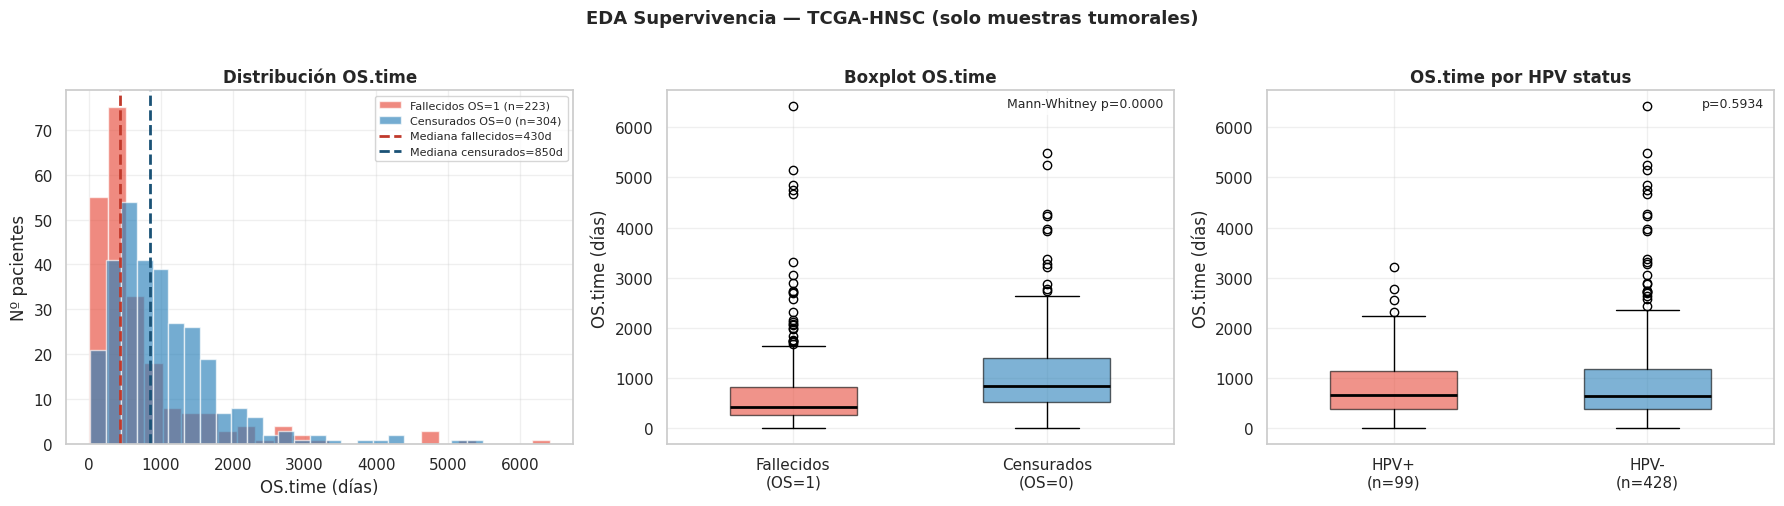

In [8]:
fallecidos = merged_clean[merged_clean[OS_STATUS] == 1]
censurados = merged_clean[merged_clean[OS_STATUS] == 0]

print(f'Fallecidos (OS=1): {len(fallecidos)} | '
      f'media={fallecidos[OS_TIME].mean():.0f}d | '
      f'mediana={fallecidos[OS_TIME].median():.0f}d')
print(f'Censurados (OS=0): {len(censurados)} | '
      f'media={censurados[OS_TIME].mean():.0f}d | '
      f'mediana={censurados[OS_TIME].median():.0f}d')
print()
print('NOTA: OS.time de censurados es tiempo mínimo (seguían vivos).')
print('      El modelo de riesgo (Cox/C-index) maneja censoring correctamente.')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# [0] Histograma
axes[0].hist(fallecidos[OS_TIME], bins=25, alpha=0.65, color='#e74c3c',
             label=f'Fallecidos OS=1 (n={len(fallecidos)})')
axes[0].hist(censurados[OS_TIME], bins=25, alpha=0.65, color='#2980b9',
             label=f'Censurados OS=0 (n={len(censurados)})')
axes[0].axvline(fallecidos[OS_TIME].median(), color='#c0392b', linestyle='--',
                linewidth=2, label=f'Mediana fallecidos={fallecidos[OS_TIME].median():.0f}d')
axes[0].axvline(censurados[OS_TIME].median(), color='#1a5276', linestyle='--',
                linewidth=2, label=f'Mediana censurados={censurados[OS_TIME].median():.0f}d')
axes[0].set_title('Distribución OS.time', fontweight='bold')
axes[0].set_xlabel('OS.time (días)'); axes[0].set_ylabel('Nº pacientes')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# [1] Boxplot OS.time
data_box = [fallecidos[OS_TIME].dropna().values, censurados[OS_TIME].dropna().values]
bp = axes[1].boxplot(data_box, patch_artist=True, widths=0.5,
                     medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('#e74c3c'); bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('#2980b9'); bp['boxes'][1].set_alpha(0.6)
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(['Fallecidos\n(OS=1)', 'Censurados\n(OS=0)'])
axes[1].set_title('Boxplot OS.time', fontweight='bold')
axes[1].set_ylabel('OS.time (días)'); axes[1].grid(alpha=0.3)
stat, pval = mannwhitneyu(fallecidos[OS_TIME].dropna(),
                           censurados[OS_TIME].dropna(), alternative='two-sided')
axes[1].text(0.98, 0.98, f'Mann-Whitney p={pval:.4f}',
             transform=axes[1].transAxes, ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# [2] OS.time por HPV
hpv_groups = [(v, merged_clean[merged_clean['hpv_status']==v][OS_TIME].dropna())
              for v in ['HPV+', 'HPV-']]
bp2 = axes[2].boxplot([g[1].values for g in hpv_groups], patch_artist=True,
                      widths=0.5, medianprops=dict(color='black', linewidth=2))
colors_hpv = ['#e74c3c', '#2980b9']
for i, box in enumerate(bp2['boxes']):
    box.set_facecolor(colors_hpv[i]); box.set_alpha(0.6)
axes[2].set_xticks([1, 2])
axes[2].set_xticklabels([f'{g[0]}\n(n={len(g[1])})' for g in hpv_groups])
axes[2].set_title('OS.time por HPV status', fontweight='bold')
axes[2].set_ylabel('OS.time (días)'); axes[2].grid(alpha=0.3)
stat_h, pval_h = mannwhitneyu(hpv_groups[0][1], hpv_groups[1][1], alternative='two-sided')
axes[2].text(0.98, 0.98, f'p={pval_h:.4f}',
             transform=axes[2].transAxes, ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

for hpv_val in ['HPV+', 'HPV-']:
    sub = merged_clean[merged_clean['hpv_status'] == hpv_val]
    print(f'{hpv_val}: n={len(sub)} | eventos={int(sub[OS_STATUS].sum())} '
          f'({100*sub[OS_STATUS].mean():.1f}%) | mediana OS={sub[OS_TIME].median():.0f}d')

plt.suptitle('EDA Supervivencia — TCGA-HNSC (solo muestras tumorales)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## PASO 6: Representatividad de los 74 pareados

Comprueba si los pacientes pareados (con muestra normal disponible) son una submuestra representativa de la cohorte o tienen sesgo sistemático.

Si el test de `OS.time` es significativo, los pareados tienen sesgo quirúrgico: las muestras normales proceden de pacientes operados, que tienden a ser más graves.

In [9]:
print('='*60)
print('REPRESENTATIVIDAD DE LOS 74 PACIENTES PAREADOS')
print('(¿Son representativos de la cohorte para usarlos como sanity check?)')
print('='*60)

merged_clean['es_pareado'] = merged_clean.index.isin(list(pareados))
pareados_df    = merged_clean[merged_clean['es_pareado'] == True]
no_pareados_df = merged_clean[merged_clean['es_pareado'] == False]

print(f'\nPareados    : {len(pareados_df)}')
print(f'No pareados : {len(no_pareados_df)}')

print('\n--- HPV STATUS ---')
for df, label in [(pareados_df,'Pareados'), (no_pareados_df,'No pareados'), (merged_clean,'Total')]:
    hpv_pct = (df['hpv_status']=='HPV+').mean()*100
    print(f'  {label:15s}: HPV+={hpv_pct:.1f}% | HPV-={(100-hpv_pct):.1f}%')

print('\n--- MORTALIDAD ---')
for df, label in [(pareados_df,'Pareados'), (no_pareados_df,'No pareados'), (merged_clean,'Total')]:
    print(f'  {label:15s}: {df[OS_STATUS].mean()*100:.1f}% fallecidos | '
          f'mediana OS={df[OS_TIME].median():.0f}d')

# Tests estadísticos
print('\n--- TESTS ESTADÍSTICOS ---')

# HPV Fisher exact
hpv_par  = (pareados_df['hpv_status'] == 'HPV+').sum()
hpv_npar = (no_pareados_df['hpv_status'] == 'HPV+').sum()
tabla = [[hpv_par, len(pareados_df)-hpv_par],
         [hpv_npar, len(no_pareados_df)-hpv_npar]]
_, p_hpv = fisher_exact(tabla)
print(f'HPV Fisher exact: p={p_hpv:.4f} '
      f'{" NO diferencia" if p_hpv > 0.05 else " SÍ diferencia"}')

# OS.time Mann-Whitney
_, p_os = mannwhitneyu(pareados_df[OS_TIME].dropna(),
                        no_pareados_df[OS_TIME].dropna(), alternative='two-sided')
print(f'OS.time Mann-Whitney: p={p_os:.4f} '
      f'{"NO diferencia" if p_os > 0.05 else " SÍ diferencia — sesgo quirúrgico"}')



REPRESENTATIVIDAD DE LOS 74 PACIENTES PAREADOS
(¿Son representativos de la cohorte para usarlos como sanity check?)

Pareados    : 74
No pareados : 453

--- HPV STATUS ---
  Pareados       : HPV+=13.5% | HPV-=86.5%
  No pareados    : HPV+=19.6% | HPV-=80.4%
  Total          : HPV+=18.8% | HPV-=81.2%

--- MORTALIDAD ---
  Pareados       : 63.5% fallecidos | mediana OS=698d
  No pareados    : 38.9% fallecidos | mediana OS=637d
  Total          : 42.3% fallecidos | mediana OS=644d

--- TESTS ESTADÍSTICOS ---
HPV Fisher exact: p=0.2614  NO diferencia
OS.time Mann-Whitney: p=0.0283  SÍ diferencia — sesgo quirúrgico


## PASO 7: Preprocesado del feature clínico HPV para fusión tardía

Codifica `hpv_status` como variable binaria (`HPV+` = 1, `HPV-` = 0) y la guarda en `hpv_encoded.csv`. Esta es la única variable clínica que entra al modelo, integrada mediante Late Fusion en NB03 para no contaminar las representaciones moleculares aprendidas por la GNN.

In [10]:
# ── Encoding HPV ──────────────────────────────────────────────────────────

hpv_encoded = pd.DataFrame(index=merged_clean.index)
hpv_encoded['hpv_positive'] = (merged_clean['hpv_status'] == 'HPV+').astype(float)

print('Feature clínico para fusión tardía:')
print(f'  Nombre    : hpv_positive')
print(f'  Tipo      : binaria (0=HPV-, 1=HPV+)')
print(f'  Cobertura : {hpv_encoded["hpv_positive"].notna().sum()}/{len(hpv_encoded)} (100%)')
print(f'  HPV+ (1)  : {int(hpv_encoded["hpv_positive"].sum())}')
print(f'  HPV- (0)  : {int((hpv_encoded["hpv_positive"]==0).sum())}')
print(f'  Desbalance: {hpv_encoded["hpv_positive"].mean()*100:.1f}% positivos')
print()
print('NOTA: El desbalance HPV (18% positivos) se maneja en NB03 mediante')
print('      stratified split por OS + HPV conjuntamente.')

# Guardar
hpv_encoded.to_csv(PROCESSED_DIR / 'hpv_encoded.csv')
print('\n hpv_encoded.csv guardado')

Feature clínico para fusión tardía:
  Nombre    : hpv_positive
  Tipo      : binaria (0=HPV-, 1=HPV+)
  Cobertura : 527/527 (100%)
  HPV+ (1)  : 99
  HPV- (0)  : 428
  Desbalance: 18.8% positivos

NOTA: El desbalance HPV (18% positivos) se maneja en NB03 mediante
      stratified split por OS + HPV conjuntamente.

 hpv_encoded.csv guardado


## PASO 8: Selección de variables clínicas

Evalúa sistemáticamente 14 variables candidatas del archivo clínico. Para cada una se reporta cobertura, distribución de valores y, según el tipo, correlación Spearman con `OS.time` (numéricas) o mortalidad y mediana OS por grupo (categóricas).

La columna `HPV+` en el desglose por grupo es la clave interpretativa: una variable cuya diferencia de mortalidad entre grupos desaparece al observar la distribución diferencial de HPV se descarta como señal confundida, no como señal independiente. El resto de descartes responden a falta de cobertura, ausencia de señal estadística o variabilidad insuficiente en la cohorte.

In [11]:
# ── VER TODAS LAS FILAS/VARIABLES DISPONIBLES ─────────────────────────────
clin = pd.read_csv(CLIN_PATH, sep='\t', low_memory=False, index_col=0)
print(f'Shape: {clin.shape}')
print(f'\nVariables disponibles (filas):')
for i, idx in enumerate(clin.index):
    if not str(idx).lower().startswith('tcga-'):
        print(f'  {i:3d}: {idx}')

Shape: (20, 528)

Variables disponibles (filas):
    0: Composite Element REF
    1: years_to_birth
    2: vital_status
    3: days_to_death
    4: days_to_last_followup
    5: tumor_tissue_site
    6: pathologic_stage
    7: pathology_T_stage
    8: pathology_N_stage
    9: pathology_M_stage
   10: gender
   11: date_of_initial_pathologic_diagnosis
   12: days_to_last_known_alive
   13: radiation_therapy
   14: histological_type
   15: number_pack_years_smoked
   16: year_of_tobacco_smoking_onset
   17: number_of_lymph_nodes
   18: race
   19: ethnicity


In [12]:
# ── EXPLORACIÓN DE VARIABLES CLÍNICAS CANDIDATAS ──────────────────────────
print('='*65)
print('EXPLORACION DE VARIABLES CLINICAS CANDIDATAS')
print('='*65)

clin = pd.read_csv(CLIN_PATH, sep='\t', low_memory=False, index_col=0)

clin_t = clin.T.copy()
clin_t.index = clin_t.index.str.upper().str[:12]
clin_t = clin_t[~clin_t.index.duplicated(keep='first')]
clin_t = clin_t.reindex(merged_clean.index)

clin_t['hpv_status'] = merged_clean['hpv_status']
clin_t[OS_TIME]      = merged_clean[OS_TIME]
clin_t[OS_STATUS]    = merged_clean[OS_STATUS]

print(f'Pacientes alineados: {clin_t.shape[0]}')

MISSING_TOKENS = {'[Not Available]', '[Not Evaluated]', '[Unknown]',
                  '[Discrepancy]', '', 'NA'}

def evaluar_variable(col, label):
    print(f'\n{"─"*55}')

    # -- Existencia --------------------------------------------------------
    if col not in clin_t.columns:
        print(f'NO ENCONTRADA: {label} ({col})')
        return

    # -- Limpieza ----------------------------------------------------------
    serie_raw = clin_t[col].replace(MISSING_TOKENS, np.nan)
    n_total   = len(serie_raw)
    n_missing = serie_raw.isna().sum()
    n_valid   = n_total - n_missing

    print(f'Variable  : {label} ({col})')
    print(f'Cobertura : {n_valid}/{n_total} validos | '
          f'{n_missing} missings ({100*n_missing/n_total:.1f}%)')

    # -- Intentar conversion numerica --------------------------------------
    serie_num = pd.to_numeric(serie_raw, errors='coerce')
    es_numerica = serie_num.notna().sum() >= 30 and \
                  serie_num.notna().sum() / max(n_valid, 1) > 0.8

    # -- Distribucion ------------------------------------------------------
    print('Distribucion:')
    if es_numerica:
        desc = serie_num.describe()
        print(f'  media={desc["mean"]:.1f} | mediana={desc["50%"]:.1f} | '
              f'min={desc["min"]:.1f} | max={desc["max"]:.1f}')
    else:
        vc = serie_raw.value_counts(dropna=False).head(8)
        for val, cnt in vc.items():
            print(f'  {str(val):40s}: {cnt}')

    # -- Correlacion con OS.time (solo si numerica) ------------------------
    if es_numerica:
        validos_idx = serie_num.dropna().index
        r, p = stats.spearmanr(
            serie_num.loc[validos_idx],
            clin_t.loc[validos_idx, OS_TIME]
        )
        print(f'Spearman con OS.time: r={r:.3f}, p={p:.3f}')

    # -- Mortalidad por grupo (solo si categorica con <= 10 categorias) ----
    n_cats = serie_raw.nunique()
    if not es_numerica and n_cats <= 10:
        print('Mortalidad y OS por grupo:')
        for val in serie_raw.dropna().unique():
            mask = serie_raw == val
            sub  = clin_t[mask]
            hpv_pct = (sub['hpv_status'] == 'HPV+').mean() * 100
            print(f'  {str(val):35s}: n={mask.sum():3d} | '
                  f'mort={sub[OS_STATUS].mean()*100:.1f}% | '
                  f'medOS={sub[OS_TIME].median():.0f}d | '
                  f'HPV+={hpv_pct:.1f}%')
    elif not es_numerica and n_cats > 10:
        print(f'  ({n_cats} categorias — demasiadas para desglosar)')

# ── EVALUAR CADA VARIABLE ──────────────────────────────────────────────────
evaluar_variable('gender',                            'Sexo')
evaluar_variable('years_to_birth',                    'Edad')
evaluar_variable('number_pack_years_smoked',          'Tabaco (pack-years)')
evaluar_variable('year_of_tobacco_smoking_onset',     'Inicio tabaco')
evaluar_variable('radiation_therapy',                 'Radioterapia')
evaluar_variable('tumor_tissue_site',                 'Localizacion anatomica')
evaluar_variable('pathologic_stage',                  'Estadio')
evaluar_variable('pathology_T_stage',                 'T stage')
evaluar_variable('pathology_N_stage',                 'N stage')
evaluar_variable('pathology_M_stage',                 'M stage')
evaluar_variable('number_of_lymph_nodes',             'No ganglios afectados')
evaluar_variable('histological_type',                 'Tipo histologico')
evaluar_variable('race',                              'Raza')
evaluar_variable('ethnicity',                         'Etnicidad')

print('\n' + '='*65)

EXPLORACION DE VARIABLES CLINICAS CANDIDATAS
Pacientes alineados: 527

───────────────────────────────────────────────────────
Variable  : Sexo (gender)
Cobertura : 527/527 validos | 0 missings (0.0%)
Distribucion:
  male                                    : 385
  female                                  : 142
Mortalidad y OS por grupo:
  male                               : n=385 | mort=39.2% | medOS=675d | HPV+=22.6%
  female                             : n=142 | mort=50.7% | medOS=575d | HPV+=8.5%

───────────────────────────────────────────────────────
Variable  : Edad (years_to_birth)
Cobertura : 527/527 validos | 0 missings (0.0%)
Distribucion:
  media=60.9 | mediana=61.0 | min=19.0 | max=89.0
Spearman con OS.time: r=-0.035, p=0.423

───────────────────────────────────────────────────────
Variable  : Tabaco (pack-years) (number_pack_years_smoked)
Cobertura : 297/527 validos | 230 missings (43.6%)
Distribucion:
  media=45.6 | mediana=40.0 | min=0.0 | max=300.0
Spearman con OS.time:

In [13]:
# ── JUSTIFICACIÓN SELECCIÓN DE VARIABLES CLÍNICAS ─────────────────────────
print('='*65)
print('EVALUACION DE VARIABLES CLINICAS — VEREDICTOS')
print('='*65)

# Criterios de descarte utilizados:
#   (A) Sin cobertura suficiente   : >20% missings
#   (B) Sin señal independiente    : Spearman p > 0.05 con OS.time
#   (C) Señal confundida con HPV   : diferencia de mortalidad explicada por
#                                    distribución diferencial de HPV+ en grupos
#   (D) Sin variabilidad           : variable casi constante en la cohorte
#   (E) Data leakage potencial     : variable de tratamiento, no de paciente

variables_eval = {
    'gender': {
        'label'   : 'Sexo (gender)',
        'criterio': 'C',
        'decision': 'DESCARTADA',
        'razon'   : (
            "Cobertura 100%, pero la diferencia de mortalidad entre sexos "
            "(mujeres 51% vs hombres 39%) se explica por HPV: las mujeres "
            "tienen 8.5% HPV+ frente al 22.6% en hombres. "
            "La variable captura HPV, no sexo per se."
        )
    },
    'years_to_birth': {
        'label'   : 'Edad (years_to_birth)',
        'criterio': 'B',
        'decision': 'DESCARTADA',
        'razon'   : (
            "Correlacion Spearman con OS.time: r=-0.035, p=0.423. "
            "Sin senal independiente. En literatura, la edad predice "
            "supervivencia en HNSC via comorbilidades (ECOG performance "
            "status), variable no disponible en TCGA."
        )
    },
    'number_pack_years_smoked': {
        'label'   : 'Tabaco pack-years',
        'criterio': 'A+B',
        'decision': 'DESCARTADA',
        'razon'   : (
            "43.6% missings y sin senal: r=0.052, p=0.367. "
            "Doble problema de cobertura y ausencia de asociacion con OS."
        )
    },
    'year_of_tobacco_smoking_onset': {
        'label'   : 'Inicio tabaco',
        'criterio': 'A+C',
        'decision': 'DESCARTADA',
        'razon'   : (
            "46.7% missings. La correlacion con OS.time (r=-0.196, p=0.001) "
            "refleja la edad del paciente (quien empezo a fumar antes, "
            "es mayor), no un efecto causal del tabaco sobre supervivencia."
        )
    },
    'radiation_therapy': {
        'label'   : 'Radioterapia',
        'criterio': 'E',
        'decision': 'DESCARTADA',
        'razon'   : (
            "Variable de tratamiento, no de paciente. "
            "La decision de dar radioterapia depende del estadio y pronostico "
            "previo — incluirla introduce data leakage."
        )
    },
    'tumor_tissue_site': {
        'label'   : 'Localizacion anatomica',
        'criterio': 'D',
        'decision': 'DESCARTADA',
        'razon'   : (
            "527/527 pacientes con valor 'head and neck'. "
            "Variable constante: sin variabilidad, sin aporte informativo."
        )
    },
    'pathologic_stage': {
        'label'   : 'Estadio patologico',
        'criterio': 'A+C',
        'decision': 'DESCARTADA',
        'razon'   : (
            "13.7% missings. La senal esta confundida con HPV: "
            "los pacientes HPV+ acumulan en Stage IVA, inflando "
            "artificialmente la mediana de supervivencia de ese estadio."
        )
    },
    'pathology_T_stage': {
        'label'   : 'T stage',
        'criterio': 'D+C',
        'decision': 'DESCARTADA',
        'razon'   : (
            "8 categorias con grupos muy pequenos (t4b n=4). "
            "El grupo 'tx' (n=39) tiene 41% HPV+, distorsionando la senal. "
            "El T stage aislado no tiene sentido clinico sin N stage."
        )
    },
    'pathology_N_stage': {
        'label'   : 'N stage',
        'criterio': 'C',
        'decision': 'DESCARTADA',
        'razon'   : (
            "Senal real (N0 mort=30% vs N3 mort=75%) pero confundida "
            "por HPV via paradoja de Wills: los HPV+ tienen mayor invasion "
            "ganglionar pero mejor pronostico, invirtiendo la interpretacion "
            "de N2 (50% HPV+). Ademas, 'nx' (n=75, 29% HPV+) sin estadificar."
        )
    },
    'pathology_M_stage': {
        'label'   : 'M stage',
        'criterio': 'A',
        'decision': 'DESCARTADA',
        'razon'   : (
            "51.4% missings. La metastasis a distancia es infrecuente "
            "en HNSC al diagnostico — la variable practica no existe "
            "en esta cohorte."
        )
    },
    'number_of_lymph_nodes': {
        'label'   : 'No ganglios afectados',
        'criterio': 'A+C',
        'decision': 'DESCARTADA',
        'razon'   : (
            "21.8% missings. Tiene senal real (r=-0.174, p<0.001) pero "
            "redundante con N stage y confundida por la paradoja de Wills: "
            "HPV+ tienen mas ganglios afectados con mejor pronostico."
        )
    },
    'histological_type': {
        'label'   : 'Tipo histologico',
        'criterio': 'D',
        'decision': 'DESCARTADA',
        'razon'   : (
            "516/527 pacientes son carcinoma de celulas escamosas. "
            "Sin variabilidad util."
        )
    },
    'race': {
        'label'   : 'Raza',
        'criterio': 'D+B',
        'decision': 'DESCARTADA',
        'razon'   : (
            "88% caucasicos. Sin variabilidad suficiente "
            "ni senal clinica independiente en HNSC."
        )
    },
    'ethnicity': {
        'label'   : 'Etnicidad',
        'criterio': 'D',
        'decision': 'DESCARTADA',
        'razon'   : (
            "94% 'not hispanic or latino'. Sin variabilidad util."
        )
    },
}

CRITERIOS = {
    'A': 'Cobertura insuficiente (>20% missings)',
    'B': 'Sin senal independiente con OS (p>0.05)',
    'C': 'Senal confundida con HPV',
    'D': 'Sin variabilidad en la cohorte',
    'E': 'Data leakage (variable de tratamiento)',
}

print('\nLeyenda de criterios de descarte:')
for k, v in CRITERIOS.items():
    print(f'  [{k}] {v}')

print()
for col, info in variables_eval.items():
    print(f"  {info['decision']:10s} [{info['criterio']}]  {info['label']}")
    print(f"               {info['razon']}")
    print()

# ── VEREDICTO FINAL ────────────────────────────────────────────────────────
print('='*65)
print('UNICA VARIABLE SELECCIONADA: HPV status (hpv_positive)')
print('='*65)
hpv_pos = merged_clean[merged_clean['hpv_status'] == 'HPV+']
hpv_neg = merged_clean[merged_clean['hpv_status'] == 'HPV-']
print(f'  Cobertura  : 527/527 (100%)')
print(f'  Mortalidad : HPV+ {hpv_pos[OS_STATUS].mean()*100:.1f}%'
      f' vs HPV- {hpv_neg[OS_STATUS].mean()*100:.1f}%')
print(f'  Evidencia  : HR aprox. 0.51, meta-analisis n=9.943 pacientes')

print('='*65)

EVALUACION DE VARIABLES CLINICAS — VEREDICTOS

Leyenda de criterios de descarte:
  [A] Cobertura insuficiente (>20% missings)
  [B] Sin senal independiente con OS (p>0.05)
  [C] Senal confundida con HPV
  [D] Sin variabilidad en la cohorte
  [E] Data leakage (variable de tratamiento)

  DESCARTADA [C]  Sexo (gender)
               Cobertura 100%, pero la diferencia de mortalidad entre sexos (mujeres 51% vs hombres 39%) se explica por HPV: las mujeres tienen 8.5% HPV+ frente al 22.6% en hombres. La variable captura HPV, no sexo per se.

  DESCARTADA [B]  Edad (years_to_birth)
               Correlacion Spearman con OS.time: r=-0.035, p=0.423. Sin senal independiente. En literatura, la edad predice supervivencia en HNSC via comorbilidades (ECOG performance status), variable no disponible en TCGA.

  DESCARTADA [A+B]  Tabaco pack-years
               43.6% missings y sin senal: r=0.052, p=0.367. Doble problema de cobertura y ausencia de asociacion con OS.

  DESCARTADA [A+C]  Inicio tabac

## PASO 9 — Guardado final de targets y barcodes

Consolida en `survival_targets_all_patients.csv` los campos estrictamente necesarios para el entrenamiento: `OS`, `OS.time`, `hpv_status`, `hpv_positive`, `os_group` y `es_pareado`. Se guardan también los barcodes ordenados en `barcodes_all_patients.txt` para que NB02 pueda alinear las matrices de expresión sin ambiguedad.

Siguiente paso: NB02: preprocesamiento de miRNA e isoformas mRNA.

In [14]:
# ── Columnas a guardar ────────────────────────────────────────────────────
# Nos quedamos estrictamente con Overall Survival (OS)
cols_survival = [c for c in [OS_STATUS, OS_TIME] if c in merged_clean.columns]

targets_df = merged_clean[cols_survival + ['hpv_status']].copy()
targets_df['hpv_positive'] = hpv_encoded['hpv_positive']
targets_df['os_group']     = merged_clean[OS_STATUS].map({0: 'censored', 1: 'deceased'})
targets_df['es_pareado']   = merged_clean['es_pareado']

# ── Guardar ───────────────────────────────────────────────────────────────
targets_out   = PROCESSED_DIR / 'survival_targets_all_patients.csv'
barcodes_all  = PROCESSED_DIR / 'barcodes_all_patients.txt'

targets_df.to_csv(targets_out)

with open(barcodes_all, 'w') as f:
    for b in sorted(merged_clean.index.tolist()):
        f.write(str(b) + '\n')

print('Archivos guardados en:', PROCESSED_DIR)
print(f'  survival_targets_all_patients.csv : {len(targets_df)} pacientes, {len(targets_df.columns)} columnas')
print(f'  barcodes_all_patients.txt         : {len(merged_clean)} barcodes tumorales')
print(f'  barcodes_por_tipo_muestra.json    : tumor/normal/meta/pareados')
print(f'  hpv_encoded.csv                   : feature clínico para fusión tardía')
print()
print('Columnas en targets_df:')
print(f'  Supervivencia : {cols_survival}')
print(f'  HPV           : hpv_status, hpv_positive')
print(f'  Grupos        : os_group, es_pareado')

Archivos guardados en: /content/drive/MyDrive/TFM/data/processed_hnsc
  survival_targets_all_patients.csv : 527 pacientes, 6 columnas
  barcodes_all_patients.txt         : 527 barcodes tumorales
  barcodes_por_tipo_muestra.json    : tumor/normal/meta/pareados
  hpv_encoded.csv                   : feature clínico para fusión tardía

Columnas en targets_df:
  Supervivencia : ['OS', 'OS.time']
  HPV           : hpv_status, hpv_positive
  Grupos        : os_group, es_pareado


## PASO 10: Resumen final de la cohorte

Print de cierre con los números definitivos: total de muestras por tipo, distribución de eventos, HPV y pareados. Sirve como verificación rápida de que todos los pasos anteriores produjeron los valores esperados antes de pasar al NB02.

In [15]:
print('='*65)
print('RESUMEN FINAL: COHORTE HNSC PARA SUPRAGRAPHNET')
print('='*65)
print(f'\nTotal pacientes (Muestras tumorales) : {len(tumor_samples)}')
print(f'  Primarios (-01)             : {count_01}')
print(f'  Metástasis (-06)            : {count_06}')
print(f'  Fallecidos (OS=1)           : {int(merged_clean[OS_STATUS].sum())}')
print(f'  Censurados (OS=0)           : {int((merged_clean[OS_STATUS]==0).sum())}')
print(f'  Tasa censura                : {100*(merged_clean[OS_STATUS]==0).mean():.1f}%')
print(f'  HPV+                        : {(merged_clean["hpv_status"]=="HPV+").sum()}')
print(f'  HPV-                        : {(merged_clean["hpv_status"]=="HPV-").sum()}')
print(f'  Con muestra normal pareada  : {len(pareados)}')
print()
print('Muestras reservadas para validación biológica (Sanity Check):')
print(f'  Normales (-11)              : {len(normal_samples)}')
print()
print('Feature clínico para fusión tardía:')
print('  hpv_positive (0/1)          : Única variable, 100% cobertura')
print()
print('Siguiente paso → NB02: Preprocesamiento de miRNA y mRNA')
print('  Input  : barcodes_all_patients.txt y barcodes_por_tipo_muestra.json')
print('  Output : Matrices de expresión filtradas y normalizadas (Tumor y Normal)')
print('  (Nota: La construcción de los grafos .pt se realizará en el NB03)')

RESUMEN FINAL: COHORTE HNSC PARA SUPRAGRAPHNET

Total pacientes (Muestras tumorales) : 530
  Primarios (-01)             : 528
  Metástasis (-06)            : 2
  Fallecidos (OS=1)           : 223
  Censurados (OS=0)           : 304
  Tasa censura                : 57.7%
  HPV+                        : 99
  HPV-                        : 428
  Con muestra normal pareada  : 74

Muestras reservadas para validación biológica (Sanity Check):
  Normales (-11)              : 74

Feature clínico para fusión tardía:
  hpv_positive (0/1)          : Única variable, 100% cobertura

Siguiente paso → NB02: Preprocesamiento de miRNA y mRNA
  Input  : barcodes_all_patients.txt y barcodes_por_tipo_muestra.json
  Output : Matrices de expresión filtradas y normalizadas (Tumor y Normal)
  (Nota: La construcción de los grafos .pt se realizará en el NB03)


## Resumen de salidas

| Fichero | Contenido |
|---|---|
| `survival_targets_all_patients.csv` | 527 pacientes × 6 columnas (OS, OS.time, hpv_status, hpv_positive, os_group, es_pareado) |
| `barcodes_all_patients.txt` | 527 barcodes de 12 chars (tumores primarios) |
| `barcodes_por_tipo_muestra.json` | Listas separadas: tumor / normal / pareados |
| `hpv_encoded.csv` | Feature clínico binario para fusión tardía (100% cobertura) |

**Cifras clave:** 527 pacientes tumorales · 223 fallecidos (OS=1) · 304 censurados (OS=0) · 99 HPV+ · 428 HPV- · 74 pareados reservados para sanity check.

**Siguiente:** NB02: Preprocesamiento multimodal (miRNA + isoformas ARNm).